In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../__datasets__/data_science_job.csv')
df.sample(3)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
7858,22850,city_114,0.926,Female,Has relevent experience,no_enrollment,Graduate,STEM,8.0,50-99,Pvt Ltd,18.0,0.0
11344,31923,city_21,0.624,NaN,Has relevent experience,Full time course,Graduate,STEM,2.0,50-99,Early Stage Startup,62.0,1.0
6297,28781,city_142,0.727,Male,Has relevent experience,no_enrollment,Graduate,STEM,12.0,50-99,Pvt Ltd,70.0,0.0


In [6]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [5]:
df.shape

(19158, 13)

In [8]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [15]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
14633,0.920,no_enrollment,Graduate,17.0,51.0
2517,0.920,no_enrollment,Masters,20.0,17.0
4017,NaN,no_enrollment,Graduate,20.0,40.0
4472,0.836,no_enrollment,NaN,16.0,156.0
5894,NaN,no_enrollment,Masters,16.0,144.0


In [17]:
len(df[cols].dropna())/len(df)

0.8968577095730244

In [18]:
newdf = df[cols].dropna()
df.shape, newdf.shape

((19158, 13), (17182, 5))

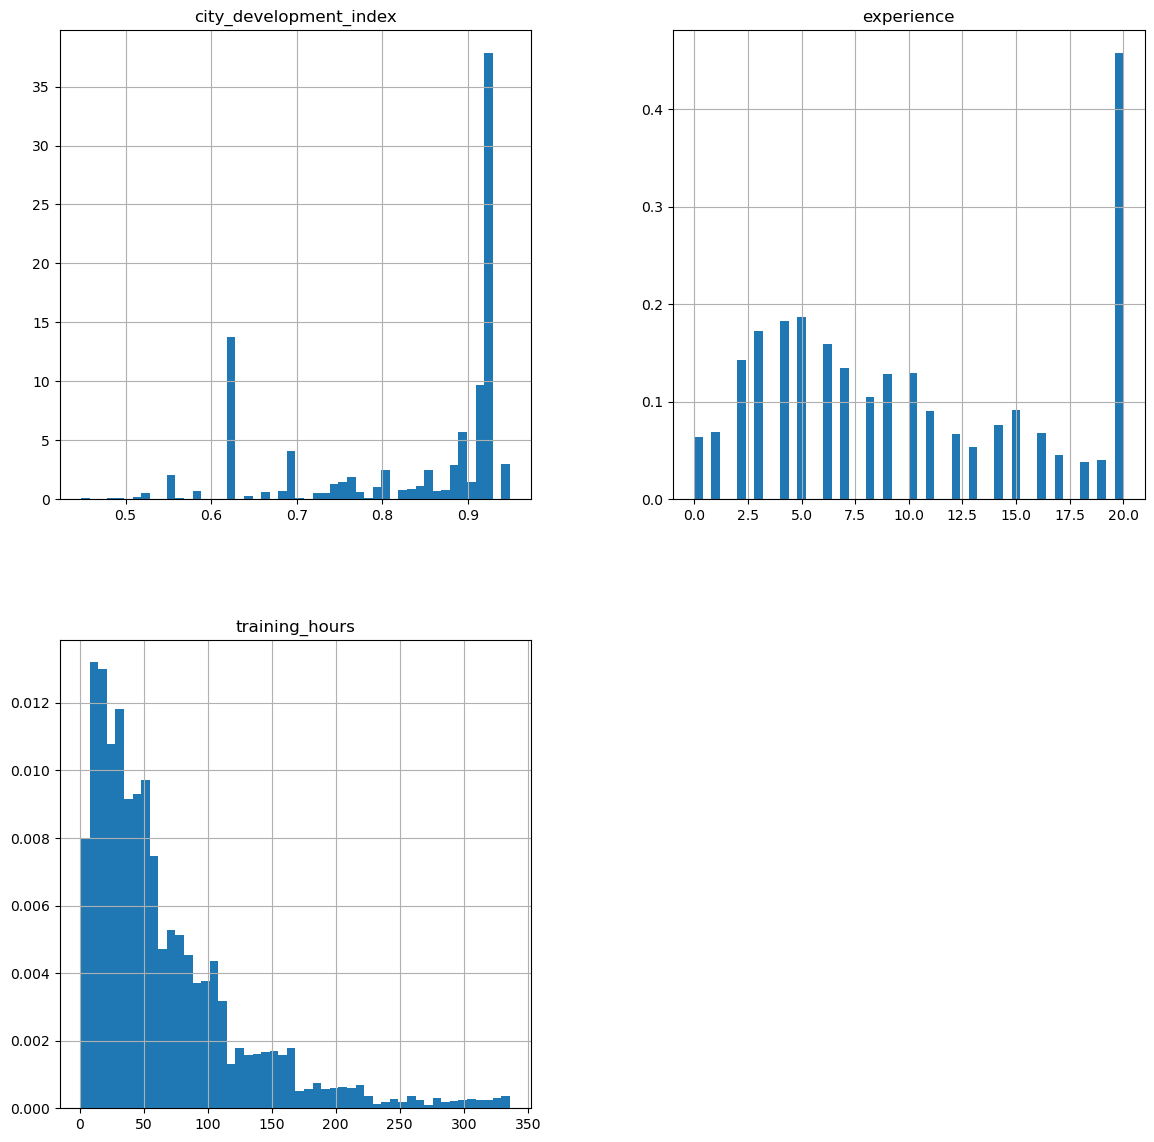

In [20]:
newdf.hist(bins = 50, density=True, figsize=(14,14))
plt.show()

<Axes: ylabel='Density'>

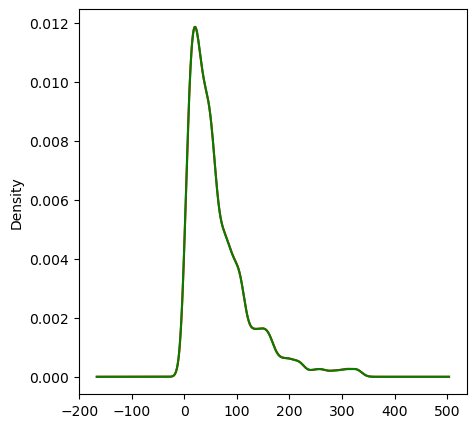

In [25]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111)

df['training_hours'].plot.density(color='red')
newdf['training_hours'].plot.density(color='green')

<Axes: >

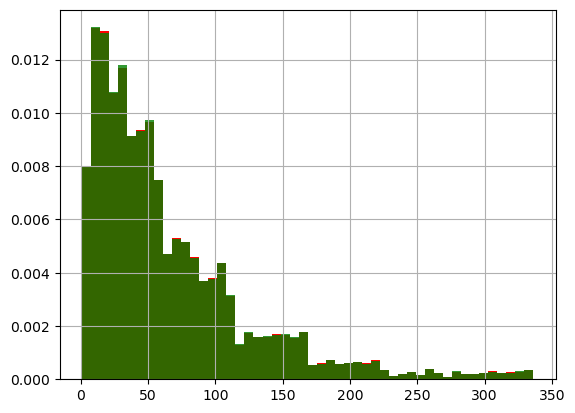

In [28]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].hist(bins=50, ax = ax, density=True, color='red')

# dummy
newdf['training_hours'].hist(bins=50, ax = ax, density=True, alpha = 0.8, color='green')


<Axes: ylabel='Density'>

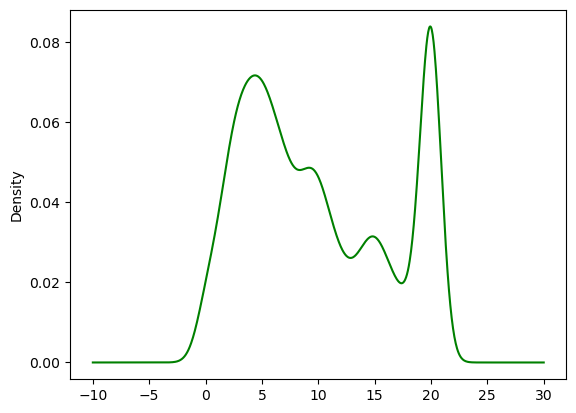

In [29]:
# after cca
newdf['experience'].plot.density(color='green')

In [30]:
temp = pd.concat([
    df['enrolled_university'].value_counts() / len(df), 
    df['enrolled_university'].value_counts() / len(df)
], axis = 1)

temp.columns = ['original', 'cca']
temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.721213
Full time course,0.196106,0.196106
Part time course,0.062533,0.062533


In [31]:
df['enrolled_university'].value_counts()

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Name: count, dtype: int64